In [9]:
import pandas as pd

train_df = pd.read_csv("data/processed/train.csv")
test_df = pd.read_csv("data/processed/test.csv")
validation_df = pd.read_csv("data/processed/validation.csv")

# join all df
df = pd.concat([train_df, test_df, validation_df], ignore_index=True)

# filter to only include where
day_in_seconds = 3600 * 24
df = df[df["tweet_age"] >= day_in_seconds]
df.head()

,verified,is_blue_verified,tweet_created_at_user_created_at_diff_log,tweet_age_sigmoid,tweet_age,tweet_created_at_hour,tweet_created_at_day_of_week,tweet_created_at_hour_sin,tweet_created_at_hour_cos,tweet_created_at_day_of_week_sin,...,user_followers_to_following_ratio_log,input_text,tweet_char_len,tweet_word_len,description_word_len,username_len,has_hashtag,has_url,has_mention,target
0,0,1,8.367278,1.0,630628,19,4,-0.965926,2.588190e-01,-0.433884,...,1.900149,Username: Joltz_btc\nUser Description: 🛠️ Tool...,245,35,25,9,0,1,1,2.346353
1,0,1,8.125524,1.0,659439,6,5,1.000000,6.123234e-17,-0.974928,...,0.997978,Username: BitcoinZac\nUser Description: Web3 g...,21,3,18,10,0,0,1,1.041393
5,0,1,6.978939,1.0,518859,18,0,-1.000000,-1.836970e-16,0.000000,...,1.822894,Username: ArtificialCZ\nUser Description: Firs...,160,24,11,12,0,0,1,2.164353
7,0,1,8.086956,1.0,963316,6,3,1.000000,6.123234e-17,0.433884,...,2.148806,Username: BTC_for_Freedom\nUser Description: F...,210,38,6,15,0,0,0,4.387728
9,0,1,7.929368,1.0,591366,21,3,-0.707107,7.071068e-01,0.433884,...,1.259968,Username: Manu08514934\nUser Description: Huma...,206,33,24,12,1,0,1,1.518514


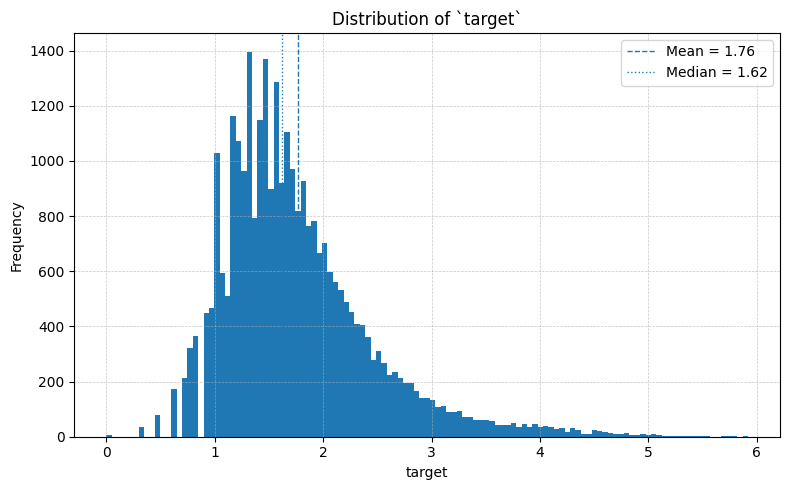

In [10]:
import matplotlib.pyplot as plt

def plot_target_distribution(df, column: str = "target") -> None:
    """
    Visualize the distribution of a numeric column with helpful context.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the column to plot.
    column : str
        Name of the numeric column whose distribution you want to inspect.
    """
    # Drop missing values and cache the series for convenience
    series = df[column].dropna()

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(8, 5))

    # Histogram with an adaptive bin count
    ax.hist(series, bins="auto")             # no explicit color → uses default
    ax.set_title(f"Distribution of `{column}`")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

    # Add mean and median reference lines
    mean_val = series.mean()
    median_val = series.median()
    ax.axvline(mean_val,   linestyle="--", linewidth=1, label=f"Mean = {mean_val:.2f}")
    ax.axvline(median_val, linestyle=":",  linewidth=1, label=f"Median = {median_val:.2f}")

    ax.legend()
    plt.tight_layout()
    plt.show()

plot_target_distribution(df)
